# GEMA Education — Competition Registrations Analysis
### Data Analytics Internship — Practical Assignment

**Objective:** Clean, analyze, and compare 2025 vs 2026 competition registration data to understand year-over-year performance, using the same calendar period (Jan 1 – Sep 4) in both years.

**Workflow:** Clean → Organize → Analyze → Visualize → Explain


## 1. Setup & Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)

# Update these paths to wherever your source files are
PATH_2025 = 'GEMA_Competition_Registrations_2025.xlsx'
PATH_2026 = 'GEMA_Competition_Registrations_2026.xlsx'

raw25 = pd.read_excel(PATH_2025)
raw26 = pd.read_excel(PATH_2026)

print("2025 raw shape:", raw25.shape)
print("2026 raw shape:", raw26.shape)
raw25.head()


2025 raw shape: (1846, 9)
2026 raw shape: (2204, 9)


,Registration ID,Registration Date,Competition,Student Name,School,Grade,City,Country,Registration Source
0,REG-2025-01556,2025-02-10,Young Innovators Challenge,Student 2025_01556,Bright Future Academy,8,Bengaluru,India,NaN
1,REG-2025-00843,2025-08-13,International Coding Olympiad,Student 2025_00843,NaN,4,Gurugram,India,WhatsApp
2,REG-2025-00035,2025-08-08,Student Speaker Competition,Student 2025_00035,Sunrise Public School,2,Abu Dhabi,UAE,Partner School
3,REG-2025-00887,2025-01-14,AI & Robotics Challenge,Student 2025_00887,Gurukul Global School,2,Abu Dhabi,UAE,Social Media
4,REG-2025-01008,2025-05-05,International Coding Olympiad,Student 2025_01008,Greenwood International School,12,Dubai,India,Social Media


## 2. Explore the Raw Data (Identify Issues)
Before cleaning anything, look at what's actually wrong with the data.

In [2]:
print("=== Missing values ===")
print("2025:\n", raw25.isna().sum())
print("\n2026:\n", raw26.isna().sum())


=== Missing values ===
2025:
 Registration ID         0
Registration Date       0
Competition             0
Student Name            0
School                 28
Grade                   0
City                   19
Country                 0
Registration Source    22
dtype: int64

2026:
 Registration ID         0
Registration Date       0
Competition             0
Student Name            0
School                 33
Grade                   0
City                   22
Country                 0
Registration Source    25
dtype: int64


In [3]:
print("Duplicate Registration IDs — 2025:", raw25['Registration ID'].duplicated().sum())
print("Duplicate Registration IDs — 2026:", raw26['Registration ID'].duplicated().sum())


Duplicate Registration IDs — 2025: 45
Duplicate Registration IDs — 2026: 53


In [4]:
print("Unique Competition values (2025):")
print(sorted(raw25['Competition'].dropna().unique()))
print()
print("Unique Competition values (2026):")
print(sorted(raw26['Competition'].dropna().unique()))


Unique Competition values (2025):
['AI & Robotics Challenge', 'International Coding Olympiad', 'International Mathematics Olympiad', 'International School Olympiad', 'International Science Olympiad', 'Intl. Coding Olympiad', 'Intl. Mathematics Olympiad', 'Intl. School Olympiad', 'Intl. Science Olympiad', 'Student Speaker Competition', 'Winter Painting Competition', 'Young Innovators Challenge']

Unique Competition values (2026):
['AI & Robotics Challenge', 'International Coding Olympiad', 'International Mathematics Olympiad', 'International School Olympiad', 'International Science Olympiad', 'Intl. Coding Olympiad', 'Intl. Mathematics Olympiad', 'Intl. School Olympiad', 'Intl. Science Olympiad', 'Student Speaker Competition', 'Winter Painting Competition', 'Young Innovators Challenge']


In [5]:
print("Unique School values (2025) — sample:")
print(sorted(raw25['School'].dropna().unique())[:15])


Unique School values (2025) — sample:
['AMITY INTERNATIONAL SCHOOL', 'Amity International School', 'Amity Intl. School', 'BRIGHT FUTURE ACADEMY', 'Bright Future Academy', 'DELHI INTERNATIONAL SCHOOL', 'DELHI PUBLIC SCHOOL', 'Delhi International School', 'Delhi Intl. School', 'Delhi Public School', 'GEMS MODERN ACADEMY', 'GEMS Modern Academy', 'GLOBAL INDIAN INTERNATIONAL SCHOOL', 'GREENWOOD INTERNATIONAL SCHOOL', 'GURUKUL GLOBAL SCHOOL']


In [6]:
# Date format check
def date_format(s):
    s = str(s)
    if re.match(r'^\d{4}-\d{2}-\d{2}$', s):
        return 'ISO (YYYY-MM-DD)'
    if re.match(r'^\d{2}/\d{2}/\d{4}$', s):
        return 'DD/MM/YYYY'
    return 'other'

print("2025 date formats:\n", raw25['Registration Date'].apply(date_format).value_counts())
print("\n2026 date formats:\n", raw26['Registration Date'].apply(date_format).value_counts())


2025 date formats:
 Registration Date
ISO (YYYY-MM-DD)    1561
DD/MM/YYYY           285
Name: count, dtype: int64

2026 date formats:
 Registration Date
ISO (YYYY-MM-DD)    1864
DD/MM/YYYY           340
Name: count, dtype: int64


In [7]:
# Test / placeholder records
print(raw25[raw25['Registration ID'].astype(str).str.startswith('TEST-')])


     Registration ID Registration Date                    Competition  \
1845  TEST-2025-0001        2025-08-20  International Coding Olympiad   

      Student Name       School  Grade   City Country Registration Source  
1845  Test Student  Test School      5  Dubai     UAE             Website  


### Issues found:
1. **Duplicate registrations** — same Registration ID appears more than once.
2. **Missing values** — blank School, City, Registration Source.
3. **Inconsistent competition names** — e.g. `'Intl. Coding Olympiad'` vs `'International Coding Olympiad'`.
4. **Inconsistent school names** — mixed case (`'GEMS MODERN ACADEMY'`) and abbreviations (`'Amity Intl. School'`).
5. **Date-format inconsistencies** — mix of ISO and `DD/MM/YYYY`.
6. **Invalid/test records** — rows with `Registration ID` starting `TEST-` and `School == 'Test School'`.


## 3. Cleaning Functions

In [8]:
def parse_date(s):
    """Handle both ISO and DD/MM/YYYY date strings."""
    s = str(s).strip()
    if re.match(r'^\d{4}-\d{2}-\d{2}$', s):
        return pd.to_datetime(s, format='%Y-%m-%d')
    if re.match(r'^\d{2}/\d{2}/\d{4}$', s):
        return pd.to_datetime(s, format='%d/%m/%Y')
    return pd.to_datetime(s, errors='coerce')

# Canonical competition names
COMP_MAP = {
    'AI & Robotics Challenge': 'AI & Robotics Challenge',
    'International Coding Olympiad': 'International Coding Olympiad',
    'Intl. Coding Olympiad': 'International Coding Olympiad',
    'International Mathematics Olympiad': 'International Mathematics Olympiad',
    'Intl. Mathematics Olympiad': 'International Mathematics Olympiad',
    'International School Olympiad': 'International School Olympiad',
    'Intl. School Olympiad': 'International School Olympiad',
    'International Science Olympiad': 'International Science Olympiad',
    'Intl. Science Olympiad': 'International Science Olympiad',
    'Student Speaker Competition': 'Student Speaker Competition',
    'Winter Painting Competition': 'Winter Painting Competition',
    'Young Innovators Challenge': 'Young Innovators Challenge',
}

# Canonical school names (lowercase key -> proper display name)
SCHOOL_MAP = {
    'amity international school': 'Amity International School',
    'amity intl. school': 'Amity International School',
    'bright future academy': 'Bright Future Academy',
    'delhi international school': 'Delhi International School',
    'delhi intl. school': 'Delhi International School',
    'delhi public school': 'Delhi Public School',
    'gems modern academy': 'GEMS Modern Academy',
    'global indian international school': 'Global Indian International School',
    'global indian intl. school': 'Global Indian International School',
    'greenwood international school': 'Greenwood International School',
    'greenwood intl. school': 'Greenwood International School',
    'gurukul global school': 'Gurukul Global School',
    'oakridge international school': 'Oakridge International School',
    'oakridge intl. school': 'Oakridge International School',
    'sunrise public school': 'Sunrise Public School',
    'the indian high school': 'The Indian High School',
    'the millennium school': 'The Millennium School',
}


In [9]:
def clean_file(df):
    """Full cleaning pipeline for one year's registrations."""
    df = df.copy()
    log = {}
    n_raw = len(df)

    # Step 1: remove test/placeholder records
    is_test = df['Registration ID'].astype(str).str.startswith('TEST-') | \
              (df['School'].astype(str).str.strip().str.lower() == 'test school')
    log['test_records_removed'] = int(is_test.sum())
    df = df[~is_test].copy()

    # Step 2: remove exact duplicate registrations
    n_before = len(df)
    df = df.drop_duplicates(subset=['Registration ID'], keep='first').copy()
    log['duplicates_removed'] = n_before - len(df)

    # Step 3: standardize dates
    df['Registration Date'] = df['Registration Date'].apply(parse_date)
    log['unparseable_dates'] = int(df['Registration Date'].isna().sum())

    # Step 4: standardize competition names
    df['Competition'] = df['Competition'].astype(str).str.strip()
    df['Competition'] = df['Competition'].map(COMP_MAP).fillna(df['Competition'])

    # Step 5: standardize school names + fill missing
    def norm_school(x):
        if pd.isna(x) or str(x).strip() == '':
            return 'Unknown School'
        key = str(x).strip().lower()
        return SCHOOL_MAP.get(key, str(x).strip())
    log['missing_school'] = int(df['School'].isna().sum())
    df['School'] = df['School'].apply(norm_school)

    # Step 6: fill other missing values
    log['missing_city'] = int(df['City'].isna().sum())
    log['missing_source'] = int(df['Registration Source'].isna().sum())
    df['City'] = df['City'].fillna('Unknown').astype(str).str.strip()
    df['Registration Source'] = df['Registration Source'].fillna('Unknown').astype(str).str.strip()

    # Step 7: trim whitespace
    for c in ['Student Name', 'Country']:
        df[c] = df[c].astype(str).str.strip()

    # Step 8: derived date fields for trend analysis
    df['Year'] = df['Registration Date'].dt.year
    df['Month'] = df['Registration Date'].dt.month
    df['MonthName'] = df['Registration Date'].dt.strftime('%b')
    df['Week'] = df['Registration Date'].dt.isocalendar().week

    log['n_raw'] = n_raw
    log['n_clean'] = len(df)

    cols = ['Registration ID','Registration Date','Year','Month','MonthName','Week',
            'Competition','Student Name','School','Grade','City','Country','Registration Source']
    return df[cols].sort_values('Registration Date').reset_index(drop=True), log


## 4. Run the Cleaning Pipeline

In [10]:
df25, log25 = clean_file(raw25)
df26, log26 = clean_file(raw26)

print("2025 cleaning log:", log25)
print("2026 cleaning log:", log26)


2025 cleaning log: {'test_records_removed': 1, 'duplicates_removed': 45, 'unparseable_dates': 0, 'missing_school': 27, 'missing_city': 18, 'missing_source': 21, 'n_raw': 1846, 'n_clean': 1800}
2026 cleaning log: {'test_records_removed': 1, 'duplicates_removed': 53, 'unparseable_dates': 0, 'missing_school': 32, 'missing_city': 21, 'missing_source': 25, 'n_raw': 2204, 'n_clean': 2150}


In [11]:
# Save cleaned outputs
df25.to_csv('clean_2025.csv', index=False)
df26.to_csv('clean_2026.csv', index=False)

with pd.ExcelWriter('GEMA_Cleaned_Registrations.xlsx') as writer:
    df25.to_excel(writer, sheet_name='2025 Cleaned', index=False)
    df26.to_excel(writer, sheet_name='2026 Cleaned', index=False)

print("Cleaned files saved.")
df25.head()


Cleaned files saved.


,Registration ID,Registration Date,Year,Month,MonthName,Week,Competition,Student Name,School,Grade,City,Country,Registration Source
0,REG-2025-01409,2025-01-01,2025,1,Jan,1,International Science Olympiad,Student 2025_01409,Oakridge International School,3,Gurugram,India,Social Media
1,REG-2025-01482,2025-01-01,2025,1,Jan,1,International Mathematics Olympiad,Student 2025_01482,The Millennium School,7,Bengaluru,India,WhatsApp
2,REG-2025-01739,2025-01-01,2025,1,Jan,1,International School Olympiad,Student 2025_01739,Oakridge International School,11,Abu Dhabi,India,Partner School
3,REG-2025-01488,2025-01-01,2025,1,Jan,1,International Coding Olympiad,Student 2025_01488,Delhi International School,8,Sharjah,UAE,Partner School
4,REG-2025-01622,2025-01-01,2025,1,Jan,1,International Science Olympiad,Student 2025_01622,Unknown School,8,Bengaluru,UAE,WhatsApp


## 5. Confirm Comparable Time Periods
Both files should cover the same calendar window so the year-over-year comparison is fair.

In [12]:
print("2025 range:", df25['Registration Date'].min(), "to", df25['Registration Date'].max())
print("2026 range:", df26['Registration Date'].min(), "to", df26['Registration Date'].max())


2025 range: 2025-01-01 00:00:00 to 2025-09-04 00:00:00
2026 range: 2026-01-01 00:00:00 to 2026-09-04 00:00:00


## 6. Competition-Level Comparison: 2026 vs 2025

In [13]:
c25 = df25.groupby('Competition').size().rename('2025')
c26 = df26.groupby('Competition').size().rename('2026')

comp = pd.concat([c25, c26], axis=1).fillna(0).astype(int)
comp['Absolute Change'] = comp['2026'] - comp['2025']
comp['% Change'] = (comp['Absolute Change'] / comp['2025'] * 100).round(1)
comp['Status'] = np.where(comp['Absolute Change'] > 0, 'Ahead of last year', 'Behind last year')
comp = comp.sort_values('% Change', ascending=False)

total_25, total_26 = comp['2025'].sum(), comp['2026'].sum()
print(f"TOTAL: {total_25} (2025) -> {total_26} (2026), {(total_26-total_25)/total_25*100:.1f}% change")
comp


TOTAL: 1800 (2025) -> 2150 (2026), 19.4% change


,2025,2026,Absolute Change,% Change,Status
Competition,,,,,
Student Speaker Competition,170,226,56,32.9,Ahead of last year
International Coding Olympiad,295,372,77,26.1,Ahead of last year
International Science Olympiad,227,284,57,25.1,Ahead of last year
International School Olympiad,218,261,43,19.7,Ahead of last year
Young Innovators Challenge,209,242,33,15.8,Ahead of last year
International Mathematics Olympiad,268,308,40,14.9,Ahead of last year
Winter Painting Competition,164,183,19,11.6,Ahead of last year
AI & Robotics Challenge,249,274,25,10.0,Ahead of last year


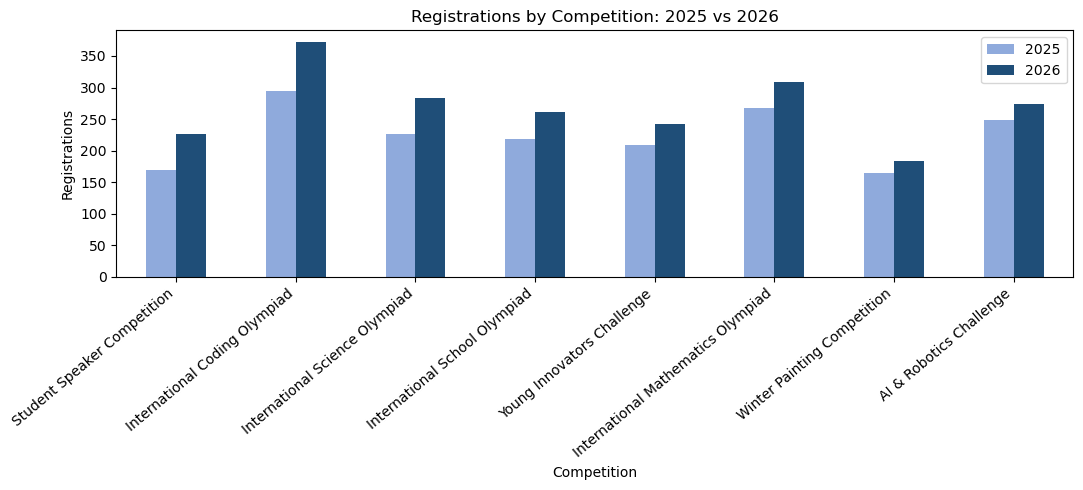

In [14]:
ax = comp[['2025','2026']].plot(kind='bar', figsize=(11,5), color=['#8FAADC','#1F4E78'])
plt.title('Registrations by Competition: 2025 vs 2026')
plt.ylabel('Registrations')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.savefig('chart_competition_comparison.png', dpi=150)
plt.show()


## 7. Trend Analysis — Monthly & Weekly

In [15]:
m25 = df25.groupby('Month').size()
m26 = df26.groupby('Month').size()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep']

monthly = pd.DataFrame({'2025': m25.reindex(range(1,10), fill_value=0).values,
                         '2026': m26.reindex(range(1,10), fill_value=0).values},
                        index=month_labels)
monthly


,2025,2026
Jan,229,287
Feb,193,228
Mar,218,288
Apr,221,224
May,234,273
Jun,209,282
Jul,250,238
Aug,216,288
Sep,30,42


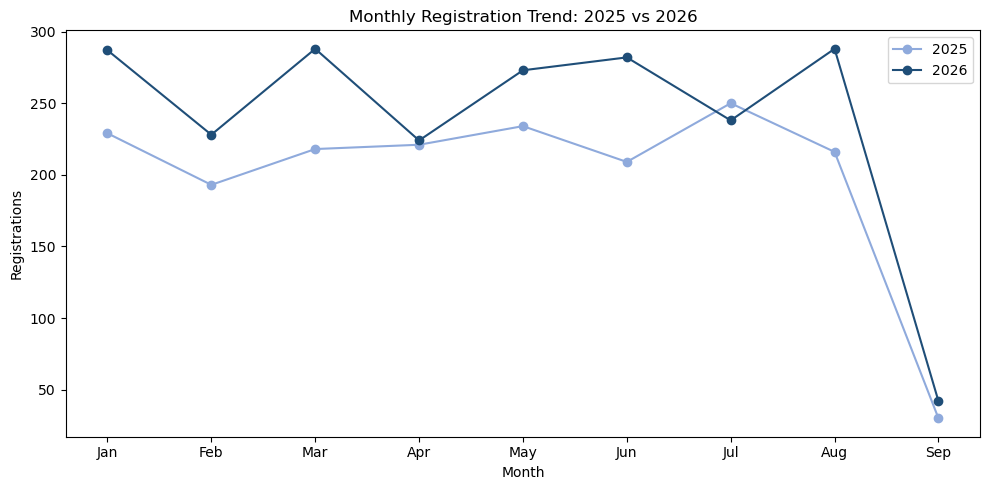

In [16]:
monthly.plot(marker='o', figsize=(10,5), color=['#8FAADC','#1F4E78'])
plt.title('Monthly Registration Trend: 2025 vs 2026')
plt.ylabel('Registrations')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('chart_monthly_trend.png', dpi=150)
plt.show()


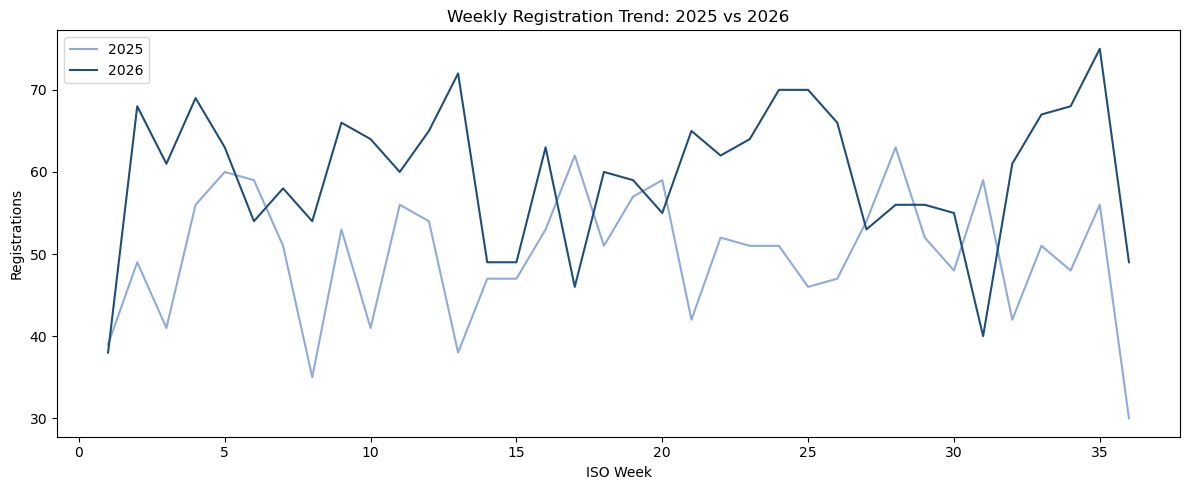

In [17]:
w25 = df25.groupby('Week').size()
w26 = df26.groupby('Week').size()
weekly = pd.concat([w25.rename('2025'), w26.rename('2026')], axis=1).fillna(0).astype(int)

weekly.plot(figsize=(12,5), color=['#8FAADC','#1F4E78'])
plt.title('Weekly Registration Trend: 2025 vs 2026')
plt.ylabel('Registrations')
plt.xlabel('ISO Week')
plt.tight_layout()
plt.savefig('chart_weekly_trend.png', dpi=150)
plt.show()


## 8. Recent Momentum Check (Last 4 Weeks vs Full-Period Pace)

In [18]:
last4_25 = df25[df25['Week'] >= 33].groupby('Competition').size()
last4_26 = df26[df26['Week'] >= 33].groupby('Competition').size()

pace = pd.concat([last4_25.rename('2025_last4wk'), last4_26.rename('2026_last4wk')], axis=1).fillna(0).astype(int)
pace['last4wk_%_change'] = ((pace['2026_last4wk'] - pace['2025_last4wk']) / pace['2025_last4wk'] * 100).round(1)
pace = pace.join(comp[['% Change']].rename(columns={'% Change':'full_period_%_change'}))
pace['momentum_gap_pp'] = (pace['last4wk_%_change'] - pace['full_period_%_change']).round(1)
pace.sort_values('momentum_gap_pp')


,2025_last4wk,2026_last4wk,last4wk_%_change,full_period_%_change,momentum_gap_pp
Competition,,,,,
International Science Olympiad,26,31,19.2,25.1,-5.9
International School Olympiad,24,28,16.7,19.7,-3.0
International Coding Olympiad,33,43,30.3,26.1,4.2
AI & Robotics Challenge,26,30,15.4,10.0,5.4
International Mathematics Olympiad,31,40,29.0,14.9,14.1
Winter Painting Competition,16,25,56.2,11.6,44.6
Student Speaker Competition,13,26,100.0,32.9,67.1
Young Innovators Challenge,16,36,125.0,15.8,109.2


**Reading this table:** a positive momentum gap means a competition is accelerating faster in the last 4 weeks than its overall year-to-date pace. A negative gap means it's losing steam recently, even if the full-period number still looks healthy.

## 9. Top 3 Growing & Bottom 3 (Slowest) Competitions

In [19]:
print("Top 3 fastest growing:")
print(comp[['2025','2026','% Change']].head(3))
print()
print("Bottom 3 (slowest growth):")
print(comp[['2025','2026','% Change']].tail(3).sort_values('% Change'))


Top 3 fastest growing:
                                2025  2026  % Change
Competition                                         
Student Speaker Competition      170   226      32.9
International Coding Olympiad    295   372      26.1
International Science Olympiad   227   284      25.1

Bottom 3 (slowest growth):
                                    2025  2026  % Change
Competition                                             
AI & Robotics Challenge              249   274      10.0
Winter Painting Competition          164   183      11.6
International Mathematics Olympiad   268   308      14.9


## 10. Other Breakdowns — Source & School

In [20]:
src = pd.concat([
    df25.groupby('Registration Source').size().rename('2025'),
    df26.groupby('Registration Source').size().rename('2026')
], axis=1).fillna(0).astype(int)
src['% Change'] = ((src['2026']-src['2025'])/src['2025']*100).round(1)
src.sort_values('2026', ascending=False)


,2025,2026,% Change
Registration Source,,,
Social Media,296,370,25.0
Email Campaign,303,366,20.8
Website,313,364,16.3
Partner School,308,355,15.3
School Outreach,274,346,26.3
WhatsApp,285,324,13.7
Unknown,21,25,19.0


In [21]:
sch = pd.concat([
    df25.groupby('School').size().rename('2025'),
    df26.groupby('School').size().rename('2026')
], axis=1).fillna(0).astype(int)
sch['% Change'] = ((sch['2026']-sch['2025'])/sch['2025']*100).round(1)
sch.sort_values('2026', ascending=False).head(10)


,2025,2026,% Change
School,,,
Amity International School,143,187,30.8
GEMS Modern Academy,145,186,28.3
Oakridge International School,158,186,17.7
Bright Future Academy,146,181,24.0
The Indian High School,143,180,25.9
Gurukul Global School,142,179,26.1
Delhi International School,149,178,19.5
Delhi Public School,146,175,19.9
Sunrise Public School,151,174,15.2


## 11. Key Findings Summary

- **Overall registrations grew 19.4%** year-over-year (1,800 → 2,150) over the identical Jan 1 – Sep 4 window.
- **Every competition grew** — none declined YoY, though growth ranged from +10.0% to +32.9%.
- **Top 3 fastest growing:** Student Speaker Competition (+32.9%), International Coding Olympiad (+26.1%), International Science Olympiad (+25.1%).
- **Slowest 3:** AI & Robotics Challenge (+10.0%), Winter Painting Competition (+11.6%), International Mathematics Olympiad (+14.9%).
- **Momentum shift:** Young Innovators Challenge roughly doubled in the last 4 weeks despite modest full-period growth — an accelerating competition worth a promotional push. International Science/School Olympiads show the opposite pattern — strong overall, but flattening recently.

### Recommendations
1. Study what's driving the Student Speaker Competition and Coding Olympiad surges and replicate for laggards.
2. Push extra promotion behind Young Innovators Challenge while it's accelerating.
3. Refresh outreach for Science/School Olympiads before their momentum fully fades.
4. Prioritize AI & Robotics, Winter Painting, and Mathematics Olympiad in the next campaign cycle.
